# Exploratory Data Analysis

## 1. ECG Beat Classification

In this part, we are going to analyse data loaded from different datasets such as MIT-BIH, MIT-BIH-Atrial-Fibrillation, INCART, European-st in order to classify properly ECG signals to 5 different classes (N: Normal, S: Superventricular, V: Ventricular, F: Fusion, Q: Unkown)

#### Why do we need this exploratory data analysis
- Understand data before modeling anything
- what does data look like?
- Is it clean?
- Is it balanced?
- Are there anomalies, noise, or missing values

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import wfdb


### 1.1 Data inspection

#### a) <u>Shape of data</u>

In [2]:
# Auto-detect project root (folder containing "data")
def get_project_root():
    path = os.getcwd()
    while True:
        if "data" in os.listdir(path):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("Could not find project root")
        path = parent

PROJECT_ROOT = get_project_root()
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "raw")

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)


Project root: c:\Users\HP\Desktop\ecg_project
Data root: c:\Users\HP\Desktop\ecg_project\data\raw


In [3]:
# Define project root
PROJECT_ROOT = os.path.dirname(os.getcwd())  # Goes from notebooks/ to project root

# Load data using project root
X_path = os.path.join(PROJECT_ROOT, "data", "processed", "beat_X.npy")
y_path = os.path.join(PROJECT_ROOT, "data", "processed", "beat_y.npy")

print(f"Loading X from: {X_path}")
print(f"Loading y from: {y_path}")

X = np.load(X_path)
y = np.load(y_path)

Loading X from: c:\Users\HP\Desktop\ecg_project\data\processed\beat_X.npy
Loading y from: c:\Users\HP\Desktop\ecg_project\data\processed\beat_y.npy


In [4]:
print(X.shape)
print(y.shape)

(1084298, 180, 1)
(1084298,)


In [5]:
# print Data Types
print(f"X dtype: {X.dtype}")
print(f"y dtype: {y.dtype}")

print("\nMemory usage:")
print(f"X: {X.nbytes:,} bytes ({X.nbytes/1024**2:.1f} MB)")
print(f"y: {y.nbytes:,} bytes ({y.nbytes/1024**2:.1f} MB)")
print(f"Total: {(X.nbytes + y.nbytes)/1024**2:.1f} MB")

X dtype: float64
y dtype: int32

Memory usage:
X: 1,561,389,120 bytes (1489.1 MB)
y: 4,337,192 bytes (4.1 MB)
Total: 1493.2 MB


In [6]:
print("\n ECG Beats with Class Names:")

class_names = {
    0: 'N - Normal',
    1: 'S - Supraventricular',
    2: 'V - Ventricular',
    3: 'F - Fusion',
    4: 'Q - Unknown'
}

data_with_names = []
for i in range(5):
    cls = int(y[i])
    class_name = class_names.get(cls, f'Class {cls}')
    

    signal = X[i, :, 0]
    peak_to_peak = signal.max() - signal.min()
    
    data_with_names.append({
        'Sample': f'Beat_{i+1:03d}',
        'Class_ID': cls,
        'Class_Name': class_name,
        'Amplitude_Range': f"{peak_to_peak:.3f} mV",
        'Duration': f"{len(signal)} samples",
        'Mean_Value': f"{signal.mean():.4f}"
    })

df_beats = pd.DataFrame(data_with_names)
display(df_beats.style
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'thead th', 'props': [('background-color', "#f0f0f000"), 
                                          ('font-weight', 'bold')]}
    ]))


 ECG Beats with Class Names:


,Sample,Class_ID,Class_Name,Amplitude_Range,Duration,Mean_Value
0,Beat_001,0,N - Normal,1.962 mV,180 samples,0.5964
1,Beat_002,0,N - Normal,1.971 mV,180 samples,0.6229
2,Beat_003,0,N - Normal,2.034 mV,180 samples,0.6175
3,Beat_004,0,N - Normal,2.028 mV,180 samples,0.5929
4,Beat_005,0,N - Normal,1.889 mV,180 samples,0.5989


In [7]:
# Check signal range
min_val_x, max_val_x = X.min(), X.max()

print(f"Signal range: [{min_val_x:.3f}, {max_val_x:.3f}]")


Signal range: [-15.091, 15.047]


#### b) <u>Sample/Class counts</u>

In [8]:
X = np.load("../data/processed/beat_X.npy")  # Shape: (1084298, 180, 1)
y = np.load("../data/processed/beat_y.npy")  # Shape: (1084298,)

print("DATASET OVERVIEW") 
print()
print(f"Total samples (beats): {X.shape[0]:,}")
print(f"Time points per beat: {X.shape[1]}")
print(f"Signal duration: {X.shape[1]/360:.2f} seconds (360 Hz)")
print(f"Number of features: {X.shape[2]} (Single lead)")
print(f"Number of classes: {len(np.unique(y))}")

DATASET OVERVIEW

Total samples (beats): 1,084,298
Time points per beat: 180
Signal duration: 0.50 seconds (360 Hz)
Number of features: 1 (Single lead)
Number of classes: 5


### 1.2 Visualization

#### a) <u>Distribution</u>

##### Signal Amplitude Distribution

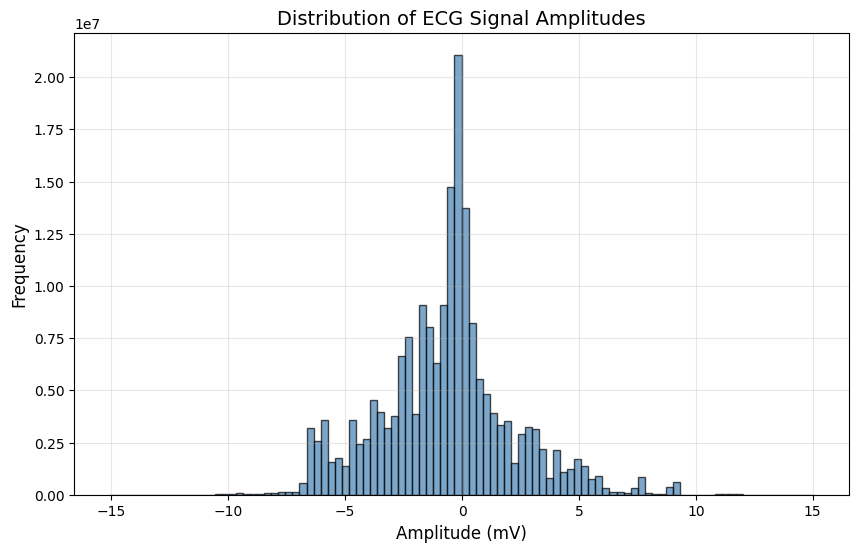

In [9]:
# Flatten all ECG signals
all_signals = X.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(all_signals, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
plt.title("Distribution of ECG Signal Amplitudes", fontsize=14)
plt.xlabel("Amplitude (mV)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

- From this distribution we can say that our signal amplitude is in normal range (-5mV to +5mV)

##### Class Label Distribution

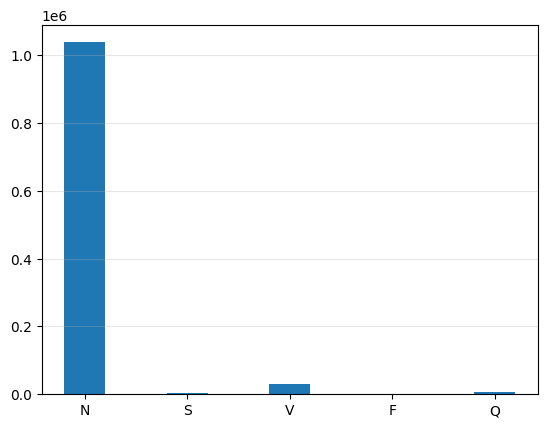

In [10]:
# How many samples per heartbeat class
unique, counts = np.unique(y, return_counts=True)
plt.bar(['N', 'S', 'V', 'F', 'Q'], counts, width=0.4)
plt.grid(axis='y', alpha=0.3)

- We can clearly see that our dataset is completely imbalanced we can get 90% just by predecting the normal class and that's not correct.

##### ECG Plot

In [11]:
def load_ecg(record_path, lead=0):
    record = wfdb.rdrecord(record_path)
    signal = record.p_signal[:, lead]
    fs = record.fs
    return signal, fs

def plot_ecg(signal, fs, start_sec=0, duration_sec=10, title="Raw ECG"):
    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)

    segment = signal[start_sample:end_sample]
    t = np.arange(len(segment)) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(t, segment)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.show()

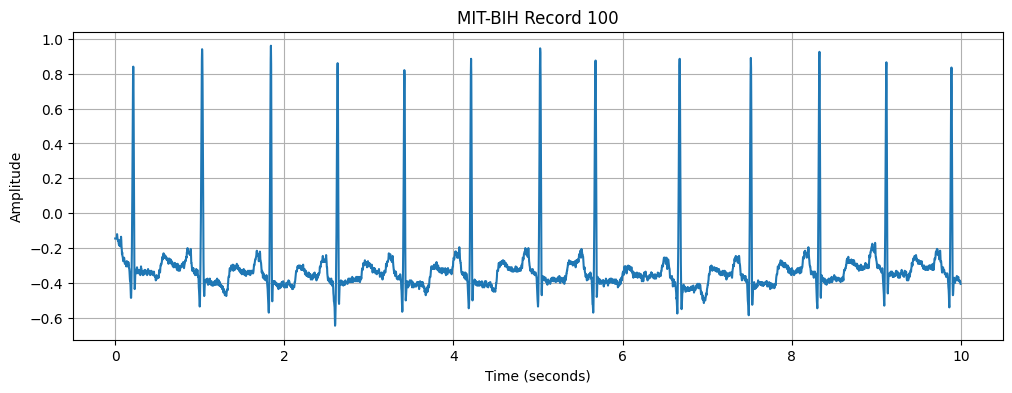

In [12]:
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "raw")
record_path = os.path.join(DATA_ROOT, "mitdb", "100")
signal, fs = load_ecg(record_path)
plot_ecg(signal, fs, duration_sec=10, title="MIT-BIH Record 100")

##### ECG Plot with R-Peaks

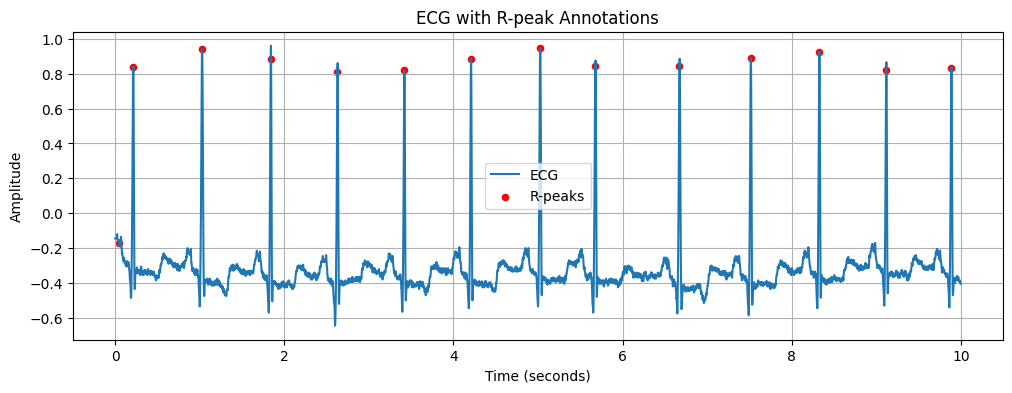

In [13]:
def plot_ecg_with_rpeaks(record_path, lead=0, start_sec=0, duration_sec=10):
    record = wfdb.rdrecord(record_path)
    ann = wfdb.rdann(record_path, "atr")

    signal = record.p_signal[:, lead]
    fs = record.fs
    r_peaks = ann.sample

    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)

    mask = (r_peaks >= start_sample) & (r_peaks <= end_sample)

    t = np.arange(start_sample, end_sample) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(t, signal[start_sample:end_sample], label="ECG")
    plt.scatter(r_peaks[mask] / fs,
                signal[r_peaks[mask]],
                color="red", s=20, label="R-peaks")

    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("ECG with R-peak Annotations")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_ecg_with_rpeaks(
    record_path=record_path,
    lead=0,
    start_sec=0,
    duration_sec=10
)


## 2. ECG Rhythm Classification

In this part, we are going to analyse data loaded from MIT-BIH-Atrial-Fibrillation dataset in order to classify properly ECG signals to 2 different classes (N: Normal rythm, AF: Atrial Fibrillation rhythm)

### 2.1 Data inspection

#### a) <u>Shape of data</u>

In [14]:
# Load data using project root
X_path_rhythm = os.path.join(PROJECT_ROOT, "data", "processed", "rhythm_X.npy")
y_path_rhythm = os.path.join(PROJECT_ROOT, "data", "processed", "rhythm_y.npy")

print(f"Loading X from: {X_path_rhythm}")
print(f"Loading y from: {y_path_rhythm}")

X_rhythm = np.load(X_path_rhythm)
y_rhythm = np.load(y_path_rhythm)

Loading X from: c:\Users\HP\Desktop\ecg_project\data\processed\rhythm_X.npy
Loading y from: c:\Users\HP\Desktop\ecg_project\data\processed\rhythm_y.npy


In [15]:
print(X_rhythm.shape)
print(y_rhythm.shape)

(168667, 1800, 1)
(168667,)


In [16]:
print("\n ECG Rhythms with Class Names:")

class_names = {
    0: 'N - Normal Rhythm',
    1: 'AF - Atrial Fibrillation'
}

data_with_names = []
for i in range(5):
    cls = int(y_rhythm[i])
    class_name = class_names.get(cls, f'Class {cls}')
    
    signal = X_rhythm[i, :, 0]
    peak_to_peak = signal.max() - signal.min()
    
    data_with_names.append({
        'Sample': f'Rhythm_{i+1:03d}',
        'Class_ID': cls,
        'Class_Name': class_name,
        'Amplitude_Range': f"{peak_to_peak:.3f} mV",
        'Duration': f"{len(signal)} samples",
        'Mean_Value': f"{signal.mean():.4f}"
    })

df_rhythms = pd.DataFrame(data_with_names)
display(df_rhythms.style
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'thead th', 'props': [('background-color', "#f0f0f000"), 
                                          ('font-weight', 'bold')]}
    ]))


 ECG Rhythms with Class Names:


,Sample,Class_ID,Class_Name,Amplitude_Range,Duration,Mean_Value
0,Rhythm_001,0,N - Normal Rhythm,3.635 mV,1800 samples,-0.3552
1,Rhythm_002,0,N - Normal Rhythm,3.655 mV,1800 samples,-0.2560
2,Rhythm_003,0,N - Normal Rhythm,3.242 mV,1800 samples,-0.2696
3,Rhythm_004,0,N - Normal Rhythm,3.218 mV,1800 samples,-0.3931
4,Rhythm_005,0,N - Normal Rhythm,3.171 mV,1800 samples,-0.3448


In [17]:
# Check signal range for the entire AF rhythm dataset
min_val_x, max_val_x = X_rhythm.min(), X_rhythm.max()

print(f"Signal range: [{min_val_x:.3f}, {max_val_x:.3f}]")

Signal range: [-8.180, 9.070]


#### b) <u>Annotation fields in AFDB</u>

In [18]:
# Inspect annotation fields for AFDB record
record_path = os.path.join(PROJECT_ROOT, "data", "raw", "afdb", "04015")
ann = wfdb.rdann(record_path, "atr")

print("=" * 60)
print("AFDB ANNOTATION FIELDS EXPLAINED")
print("=" * 60)

print(f"\n1. ann.sample (R-peak locations)")
print(f"    Shape: {ann.sample.shape}")
print(f"    First 10: {ann.sample[:10]}")
print(f"   → Sample indices where annotations occur")

print(f"\n2. ann.symbol (Beat type symbols)")
print(f"   Total: {len(ann.symbol)}")
print(f"   Unique: {set(ann.symbol)}")
print(f"   First 10: {ann.symbol[:10]}")

print(f"\n3. ann.aux_note (Rhythm annotations)")
aux_non_empty = [(i, s, ann.aux_note[i]) for i, s in enumerate(ann.symbol) if ann.aux_note[i].strip('\x00').strip() != '']
print(f"   Non-empty count: {len(aux_non_empty)}")
print(f"   First 10 non-empty:")
for idx, sym, note in aux_non_empty[:10]:
    note_clean = note.strip('\x00').strip()
    print(f"     Index {idx}: symbol='{sym}', aux_note='{note_clean}', sample={ann.sample[idx]}")

print(f"\n4. ann.subtype")
print(f"   Unique: {set(ann.subtype)}")
print(f"   First 10: {ann.subtype[:10]}")

print(f"\n5. ann.chan (Channel number)")
print(f"   Unique: {set(ann.chan)}")

print(f"\n6. ann.num")
print(f"   Unique: {set(ann.num)}")
print(f"   First 10: {ann.num[:10]}")

print(f"\n7. ann.fs (Sampling frequency)")
print(f"   {ann.fs} Hz")

# Count rhythm types
from collections import Counter
rhythm_types = [ann.aux_note[i].strip('\x00').strip() for i in range(len(ann.aux_note)) if ann.aux_note[i].strip('\x00').strip() != '']
print(f"\n8. Rhythm type counts:")
for rhythm, count in Counter(rhythm_types).items():
    print(f"   '{rhythm}': {count} transitions")

AFDB ANNOTATION FIELDS EXPLAINED

1. ann.sample (R-peak locations)
    Shape: (15,)
    First 10: [     30  102584  119604  121773  122194  133348  166857 1096245 1098054
 1135296]
   → Sample indices where annotations occur

2. ann.symbol (Beat type symbols)
   Total: 15
   Unique: {'+'}
   First 10: ['+', '+', '+', '+', '+', '+', '+', '+', '+', '+']

3. ann.aux_note (Rhythm annotations)
   Non-empty count: 15
   First 10 non-empty:
     Index 0: symbol='+', aux_note='N', sample=30
     Index 1: symbol='+', aux_note='AF', sample=102584
     Index 2: symbol='+', aux_note='N', sample=119604
     Index 3: symbol='+', aux_note='AF', sample=121773
     Index 4: symbol='+', aux_note='N', sample=122194
     Index 5: symbol='+', aux_note='AF', sample=133348
     Index 6: symbol='+', aux_note='N', sample=166857
     Index 7: symbol='+', aux_note='AF', sample=1096245
     Index 8: symbol='+', aux_note='N', sample=1098054
     Index 9: symbol='+', aux_note='AF', sample=1135296

4. ann.subtype
  

#### c) <u>Sample/Class counts</u>

In [19]:
print("DATASET OVERVIEW") 
print()
print(f"Total samples (windows): {X_rhythm.shape[0]:,}")
print(f"Time points per window: {X_rhythm.shape[1]}")
print(f"Signal duration: {X_rhythm.shape[1]/360:.2f} seconds (360 Hz)")
print(f"Number of features: {X_rhythm.shape[2]} (Single lead)")
print(f"Number of classes: {len(np.unique(y_rhythm))}")

DATASET OVERVIEW

Total samples (windows): 168,667
Time points per window: 1800
Signal duration: 5.00 seconds (360 Hz)
Number of features: 1 (Single lead)
Number of classes: 2


### 2.2 Visualization

#### a) <u>Distribution</u>

##### Signal Amplitude Distribution

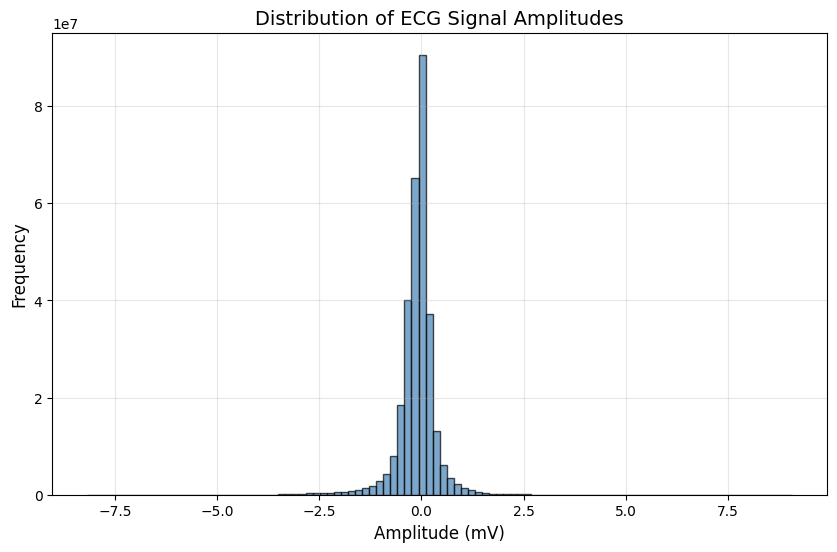

In [20]:
# Flatten all ECG signals
all_signals = X_rhythm.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(all_signals, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
plt.title("Distribution of ECG Signal Amplitudes", fontsize=14)
plt.xlabel("Amplitude (mV)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

- From this distribution we can say that our signal amplitude is in a healthy range (-2.5mV to +2.5mV)

##### Class Label Distribution

[109814  58853]


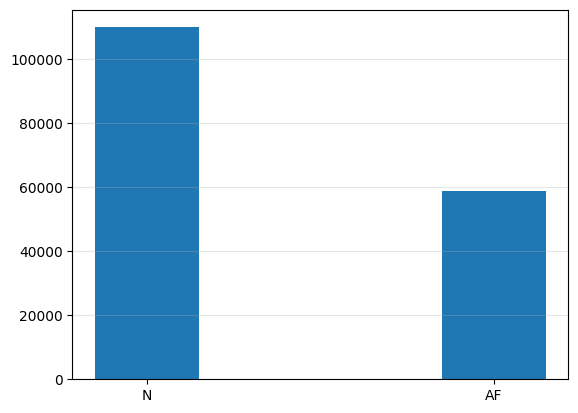

In [21]:
# How many samples per window class
unique, counts = np.unique(y_rhythm, return_counts=True)
print(counts)
plt.bar(['N', 'AF'], counts, width=0.3)
plt.grid(axis='y', alpha=0.3)

- We can see that our dataset is little bit imbalanced. We must increase Atrial fibrillation class in training to achieve better accuracy.

##### ECG Plot

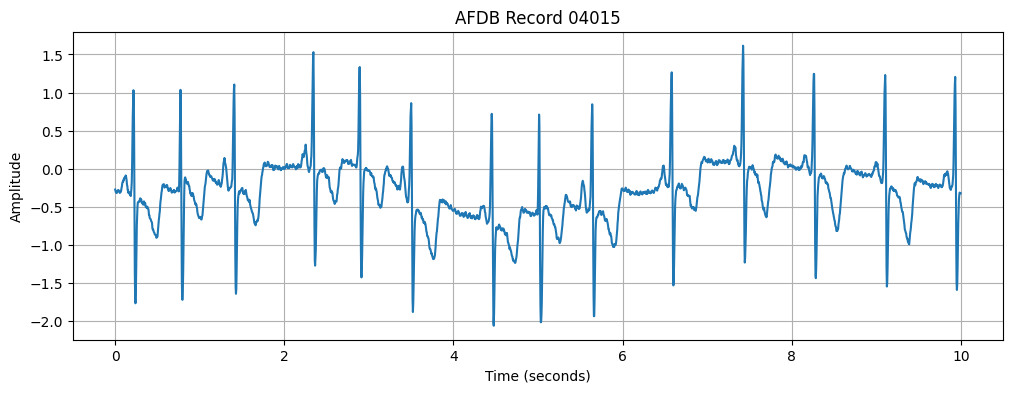

In [22]:
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "raw")
record_path = os.path.join(DATA_ROOT, "afdb", "04015")
signal, fs = load_ecg(record_path)
plot_ecg(signal, fs, duration_sec=10, title="AFDB Record 04015")

##### ECG Plot with AF Windows

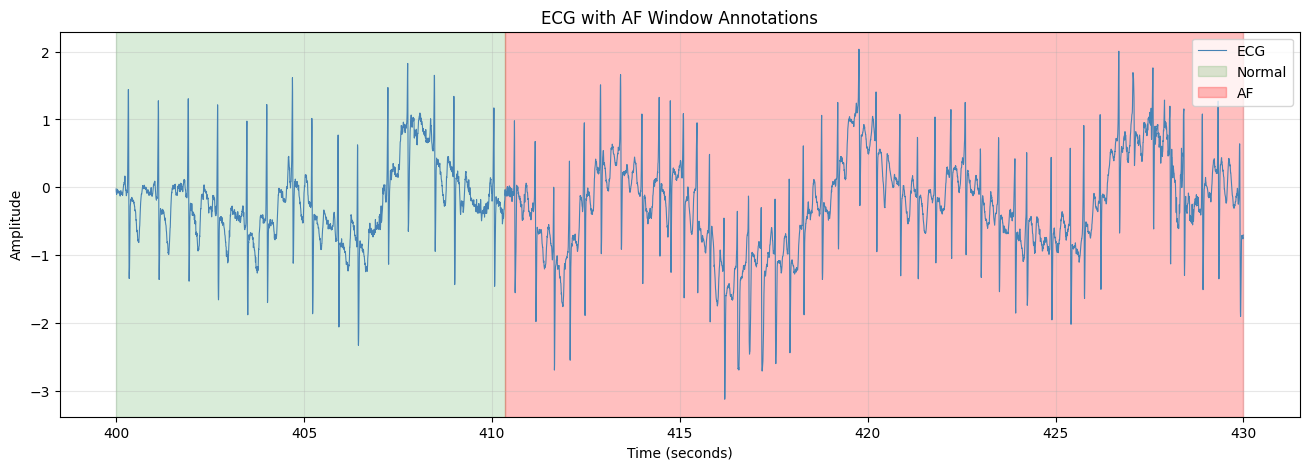

In [23]:
def plot_ecg_with_af_windows(record_path, lead=0, start_sec=0, duration_sec=30):
    record = wfdb.rdrecord(record_path)
    ann = wfdb.rdann(record_path, "atr")

    signal = record.p_signal[:, lead]
    fs = record.fs

    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)
    t = np.arange(start_sample, end_sample) / fs

    plt.figure(figsize=(16, 5))
    plt.plot(t, signal[start_sample:end_sample], color='steelblue', linewidth=0.8, label="ECG")

    af_labeled = False
    n_labeled = False

    # Shade AF and Normal regions based on rhythm annotations
    for i in range(len(ann.sample)): # ann.sample contains the sample indices of annotations (heartbeats + rhythm change markers)
        sym = ann.aux_note[i].strip('\x00').strip() # Strips null characters (\x00) and whitespace
        region_start = ann.sample[i]
        region_end = ann.sample[i + 1] if i + 1 < len(ann.sample) else len(signal)

        # Clip to visible window
        vis_start = max(region_start, start_sample)
        vis_end = min(region_end, end_sample)

        if vis_start >= vis_end:
            continue

        t_start = vis_start / fs
        t_end = vis_end / fs

        if sym == 'AF':
            plt.axvspan(t_start, t_end, alpha=0.25, color='red', label='AF' if not af_labeled else "")
            af_labeled = True
        elif sym == 'N':
            plt.axvspan(t_start, t_end, alpha=0.15, color='green', label='Normal' if not n_labeled else "")
            n_labeled = True

    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("ECG with AF Window Annotations")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Start at ~400s to see the transition between Normal and AF
plot_ecg_with_af_windows(
    record_path=record_path,
    lead=0,
    start_sec=400, # override start_sec=0 with 400 when calling the function.
    duration_sec=30
)